/tmp/ipykernel_2138912/334005295.py:95: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('cool')
/tmp/ipykernel_2138912/334005295.py:132: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


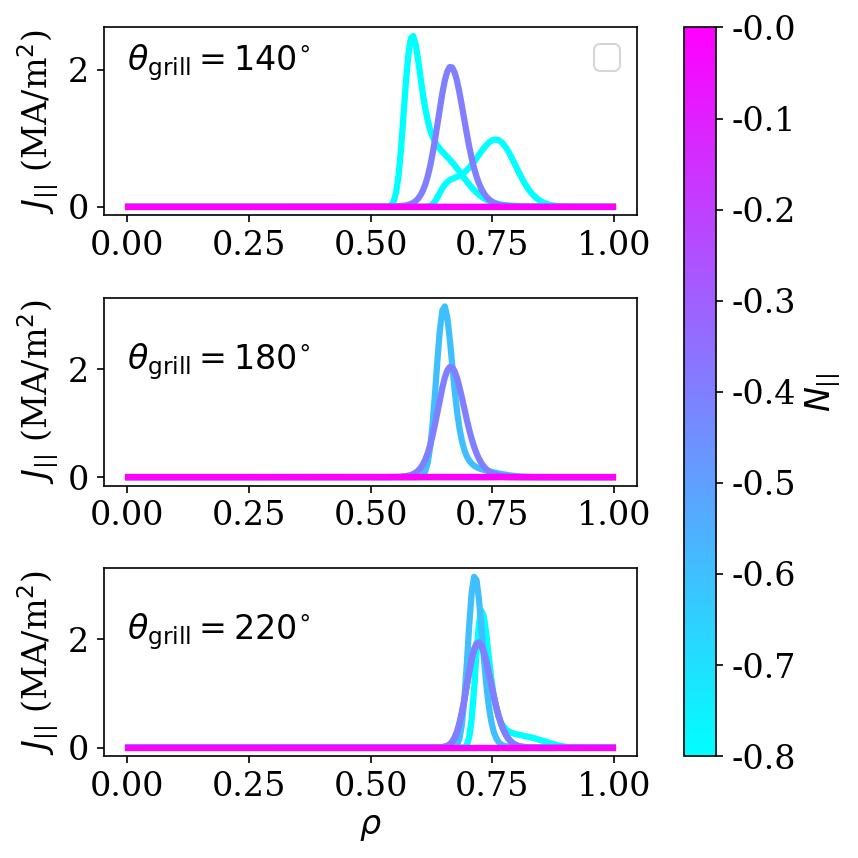

In [3]:
from netCDF4 import Dataset
from sys import argv
import os
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import matplotlib.cm as cm

plot_var = 'curr_parallel'

with plt.rc_context({
    #"text.usetex": True,
    "font.family": "serif",
    #"font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    "figure.autolayout":True,
    #"legend.frameon" : False,
    "lines.linewidth" : 3.0,
    "lines.markeredgewidth" : 0.0,
    "lines.markersize" : 6.0

}):
    
    fig = plt.figure('fig_offset', figsize=(6,6),dpi = 150)
    gs = mpl.gridspec.GridSpec(3,2, figure=fig, width_ratios=[1,0.06])
    axs = {}
    axs[1] = fig.add_subplot(gs[0,0])
    axs[2] = fig.add_subplot(gs[:,1])
    axs[3] = fig.add_subplot(gs[1,0])
    axs[4] = fig.add_subplot(gs[2,0])

    
    ax1 = axs[1]
    ax1cb = axs[2]
    ax2 = axs[3]
    ax3 = axs[4]
    
    # First just find the fastran.nc file ================
    cwd = os.getcwd()
    SCAN_dir = cwd+'/SCAN'
    sims = [f for f in os.listdir(SCAN_dir) if f.startswith('simulation_') and not f.endswith('.conf') and not f.endswith('log')]

    npar_array = []
    current_prof_array = []
    thgrill_array = []
    for sim in sims:
        work_dir = SCAN_dir+'/'+sim+'/work'
        
        #fastran_dir = [f for f in os.listdir(work_dir) if f.startswith('fastran_tr_')]
        #ffile = work_dir+'/'+fastran_dir[0]+'/fastran.nc'
    
        #toray_dir = [f for f in os.listdir(work_dir) if f.startswith('fastran_ec_')]
        #toray_file = work_dir+'/'+toray_dir[0]+'/toray.nc'
        genray_dir = [f for f in os.listdir(work_dir) if f.startswith('fastran_lh_')]
        lhfile = work_dir+'/'+genray_dir[0]+'/genray.nc'
        gfile = work_dir+'/'+genray_dir[0]+'/g000001.00001'
    
        #rootgrp = Dataset(ffile)
        #geqdsk = omfit_eqdsk.OMFITgeqdsk(gfile)
        lhgrp = Dataset(lhfile)
    
        param_file = SCAN_dir+'/'+sim+'/'+'parameters.conf'
        params_table = np.genfromtxt(param_file,dtype=None,usecols=[1,2])
    
        param_name_0,param_val_0 = params_table[-1]
        #param_name_1,param_val_1 = params_table[-2]
        anmax_name,anmax_val = params_table[-2]
        anmin_name,anmin_val = params_table[-3]
        npar = (anmin_val+anmax_val)/2
        npar_array.append(npar)
        
    #=====================================================
        rho = lhgrp['rho_bin_center'][:]
        cur_parallel = lhgrp['s_cur_den_parallel'][:]
        cur_parallel = cur_parallel / 1e2  # from A/cm^2 to MA/m^2
        var_dic = {'curr_parallel':cur_parallel}
        lw = 2
        c1 = 'green'
        c2 = 'lime'
        c3 = 'magenta'
        c4 = 'darkviolet'
        c5 = 'dodgerblue'
        c6 = 'cyan'

        current_prof_array.append(var_dic[plot_var])
        thgrill_array.append(param_val_0)

    order_thgrill = np.argsort(thgrill_array)
        
    cvar = npar_array
    yvar = current_prof_array
    xvar = rho
    
    # set colors for colorbar
    cmap = cm.get_cmap('cool')
    cmin = min(cvar)
    cmax = max(cvar)
    cs = (cvar-cmin)/(cmax-cmin)
    c = cmap(cs)
    order = np.argsort(cs)

    # make colorbar
    Ncb = 5
    ticklabels = np.array(-0.1*np.arange(0,9))
    ticks = (ticklabels-min(ticklabels))/(max(ticklabels)-min(ticklabels))
    #ticks = np.linspace(0,1,Ncb); ticklabels = np.linspace(cmin,cmax,Ncb)
    cb1 = mpl.colorbar.ColorbarBase(ax1cb, orientation='vertical',cmap=cmap, ticks=ticks)
    ticklabels = ['{:1.1f}'.format(x) for x in ticklabels]
    ticklabels[0] = f'{ticklabels[0]}'
    ticklabels[-1] = f'{ticklabels[-1]}'
    cb1.set_ticklabels(ticklabels)

    ax1cb.set_ylabel('${N_\\mathrm{||}}$')
    
    for i in order:
        if i in order_thgrill[:5]:
            ax1.plot(xvar,yvar[i],c=c[i])
        elif i in order_thgrill[5:10]:
            ax2.plot(xvar,yvar[i],c=c[i])
        elif i in order_thgrill[10:]:
            ax3.plot(xvar,yvar[i],c=c[i])

    ax1.text(0,2,'$\\theta_\\mathrm{grill} = 140^{\\circ}$')
    ax2.text(0,2,'$\\theta_\\mathrm{grill} = 180^{\\circ}$')
    ax3.text(0,2,'$\\theta_\\mathrm{grill} = 220^{\\circ}$')

    ax1.set_ylabel('$J_\\mathrm{||}$ (MA/m$^2$)')
    ax2.set_ylabel('$J_\\mathrm{||}$ (MA/m$^2$)')
    ax3.set_ylabel('$J_\\mathrm{||}$ (MA/m$^2$)')
    ax3.set_xlabel('$\\rho$')
    fig.tight_layout()
    ax1.legend()
    plt.show()


In [13]:
#print(lhgrp.variables)